# Добровольский А.В. ИУ5-23М
## Лабораторная работа №3
### Методы многомерного поиска. 

**Задача:** найти минимум тестовой функции Розенброка методами сопряженных градиентов и квазиньютоновскими методами.

В работе реализованы методы:

1. метод Флетчера-Ривза;
2. метод Полака-Рибьера;
3. метод DFP;
4. метод BFGS;
5. метод L-BFGS.



In [1]:
import itertools
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import root

pd.set_option('display.precision', 8)



## 1. Выбор варианта и постановка задачи

Минимизируется обобщенная функция Розенброка:

$$
f(x)=\sum_{i=1}^{n-1}\left(a(x_{i+1}-x_i^2)^2+b(x_i-1)^2\right)+f_0.
$$


In [2]:
a, b, f0, n = 250, 2, 60, 2

# Классическая начальная точка для функции Розенброка.
x0 = np.array([-1.2 if i % 2 == 0 else 1.0 for i in range(n)], dtype=float)

x0


array([-1.2,  1. ])


## 2. Функция, градиент и служебные функции

Параметр `f0` только сдвигает значение функции и не влияет на градиент и положение стационарной точки.


In [3]:

def rosenbrock_generalized(x, a=a, b=b, f0=f0):
    """Обобщенная функция Розенброка."""
    x = np.asarray(x, dtype=float)
    return float(np.sum(a * (x[1:] - x[:-1]**2)**2 + b * (x[:-1] - 1)**2) + f0)


def grad_rosenbrock(x, a=a, b=b, f0=f0):
    """Аналитический градиент обобщенной функции Розенброка."""
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x, dtype=float)
    for i in range(len(x) - 1):
        t = x[i + 1] - x[i]**2
        grad[i] += -4 * a * x[i] * t + 2 * b * (x[i] - 1)
        grad[i + 1] += 2 * a * t
    return grad


def numerical_hessian(grad_func, x, h=1e-5):
    """Численная аппроксимация матрицы Гессе по центральным разностям градиента."""
    x = np.asarray(x, dtype=float)
    H = np.zeros((len(x), len(x)))
    for j in range(len(x)):
        e = np.zeros(len(x))
        e[j] = 1.0
        H[:, j] = (grad_func(x + h * e) - grad_func(x - h * e)) / (2 * h)
    return 0.5 * (H + H.T)


def find_stationary_points(grad_func, n, grid_min=-2.0, grid_max=2.0, points_per_axis=5, tol=1e-6):
    """Поиск стационарных точек из множества стартовых точек методом scipy.optimize.root."""
    grid = np.linspace(grid_min, grid_max, points_per_axis)
    solutions = []
    for start in itertools.product(grid, repeat=n):
        sol = root(grad_func, np.array(start, dtype=float), method='hybr')
        if sol.success and np.linalg.norm(grad_func(sol.x)) < tol:
            x_candidate = np.round(sol.x, 10)
            if all(np.linalg.norm(x_candidate - x_saved) > 1e-5 for x_saved in solutions):
                solutions.append(x_candidate)
    return solutions



## 3. Поиск стационарных точек

Стационарные точки определяются из условия $\nabla f(x)=0$. Для выбранного варианта выполняется численный поиск из сетки начальных точек.


In [4]:

stationary_points = find_stationary_points(grad_rosenbrock, n=n)

stationary_df = pd.DataFrame([
    {
        'stationary_point': np.array2string(x, precision=8),
        'f(x)': rosenbrock_generalized(x),
        '||grad f(x)||': np.linalg.norm(grad_rosenbrock(x)),
        'min eig(H)': np.min(np.linalg.eigvalsh(numerical_hessian(grad_rosenbrock, x))),
    }
    for x in stationary_points
])
stationary_df


,stationary_point,f(x),||grad f(x)||,min eig(H)
0,[1. 1.],60.0,0.0,0.798977



**Проверка допустимости.** Задача является задачей безусловной оптимизации на $\mathbb{R}^n$, поэтому найденные точки допустимы. Для точки минимума дополнительно проверяется малая норма градиента и положительная определенность матрицы Гессе.



## 4. Одномерный поиск и критерии остановки

Критерии остановки:

1. $\|\nabla f(x_k)\| \leq \varepsilon$;
2. достижение максимального числа итераций;
3. два последовательных одновременных выполнения условий малости шага и изменения функции.


In [5]:

def line_search_armijo(f, grad, x, d, alpha0=1.0, c1=1e-4, tau=0.5, min_alpha=1e-12, max_iter=80):
    """Backtracking line search with Armijo sufficient decrease condition."""
    x = np.asarray(x, dtype=float)
    d = np.asarray(d, dtype=float)
    f0_val = f(x)
    g0 = grad(x)
    directional_derivative = float(g0 @ d)

    if directional_derivative >= 0:
        # Если направление не является направлением убывания, переходим к антиградиенту.
        d = -g0
        directional_derivative = float(g0 @ d)

    alpha = float(alpha0)
    for _ in range(max_iter):
        new_val = f(x + alpha * d)
        if np.isfinite(new_val) and new_val <= f0_val + c1 * alpha * directional_derivative:
            return alpha
        alpha *= tau
        if alpha < min_alpha:
            return alpha
    return alpha


@dataclass
class OptResult:
    method: str
    x: np.ndarray
    f: float
    grad_norm: float
    n_iter: int
    time_sec: float
    converged: bool
    reason: str
    history: list


def check_stop(history, eps_grad, eps_x, eps_f, k, max_iter):
    last = history[-1]
    if last['grad_norm'] <= eps_grad:
        return True, 'Норма градиента меньше eps_grad'
    if k >= max_iter:
        return True, 'Достигнут лимит итераций'
    if len(history) >= 3:
        last_ok = history[-1]['step_norm'] <= eps_x and history[-1]['df_abs'] <= eps_f
        prev_ok = history[-2]['step_norm'] <= eps_x and history[-2]['df_abs'] <= eps_f
        if last_ok and prev_ok:
            return True, 'Два раза подряд выполнены условия по |dx| и |df|'
    return False, ''



## 5. Методы сопряженных градиентов

Реализованы:

- метод Флетчера-Ривза;
- метод Полака-Рибьера с отсечкой $\beta_k=\max(0,\beta_k)$ и перезапуском каждые $n$ итераций.


In [ ]:

def optimize_cg(f, grad, x0, method='FR', eps_grad=1e-5, eps_x=1e-8, eps_f=1e-10,
                max_iter=5000, restart_every_n=True):
    start_time = time.perf_counter()
    x = np.asarray(x0, dtype=float).copy()
    n_dim = len(x)
    g = grad(x)
    d = -g

    history = [{
        'iter': 0,
        'x': x.copy(),
        'f': f(x),
        'grad_norm': float(np.linalg.norm(g)),
        'alpha': np.nan,
        'step_norm': np.nan,
        'df_abs': np.nan,
    }]

    reason = ''
    converged = False

    for k in range(max_iter):
        if np.linalg.norm(g) <= eps_grad:
            reason = 'Норма градиента меньше eps_grad'
            converged = True
            break

        # Если направление перестало быть направлением убывания, сбрасываем его.
        if float(g @ d) >= 0:
            d = -g

        alpha = line_search_armijo(f, grad, x, d)
        x_new = x + alpha * d
        g_new = grad(x_new)
        f_old = f(x)
        f_new = f(x_new)

        history.append({
            'iter': k + 1,
            'x': x_new.copy(),
            'f': float(f_new),
            'grad_norm': float(np.linalg.norm(g_new)),
            'alpha': float(alpha),
            'step_norm': float(np.linalg.norm(x_new - x)),
            'df_abs': float(abs(f_new - f_old)),
        })

        stop, reason = check_stop(history, eps_grad, eps_x, eps_f, k + 1, max_iter)
        if stop:
            converged = reason != 'Достигнут лимит итераций'
            x, g = x_new, g_new
            break

        if method.upper() == 'FR':
            beta = float((g_new @ g_new) / max(g @ g, 1e-300))
        elif method.upper() in {'PR', 'PRP', 'POLAK-RIBIERE'}:
            if restart_every_n and ((k + 1) % n_dim == 0):
                beta = 0.0
            else:
                beta = float((g_new @ (g_new - g)) / max(g @ g, 1e-300))
                beta = max(0.0, beta)
        else:
            raise ValueError('Unknown CG method')

        d = -g_new + beta * d
        x, g = x_new, g_new
    else:
        reason = 'Достигнут лимит итераций'

    elapsed = time.perf_counter() - start_time
    method_name = 'Fletcher-Reeves' if method.upper() == 'FR' else 'Polak-Ribiere'
    return OptResult(method_name, x, f(x), float(np.linalg.norm(grad(x))),
                     len(history) - 1, elapsed, converged, reason, history)



## 6. Квазиньютоновские методы DFP, BFGS и L-BFGS

Во всех методах матрица или неявное приближение используется для построения направления поиска. Если направление не является направлением убывания, выполняется сброс к антиградиенту.


In [7]:

def optimize_dfp(f, grad, x0, eps_grad=1e-5, eps_x=1e-8, eps_f=1e-10, max_iter=1000):
    start_time = time.perf_counter()
    x = np.asarray(x0, dtype=float).copy()
    n_dim = len(x)
    H = np.eye(n_dim)
    g = grad(x)

    history = [{'iter': 0, 'x': x.copy(), 'f': f(x), 'grad_norm': float(np.linalg.norm(g)),
                'alpha': np.nan, 'step_norm': np.nan, 'df_abs': np.nan}]
    reason = ''
    converged = False

    for k in range(max_iter):
        if np.linalg.norm(g) <= eps_grad:
            reason = 'Норма градиента меньше eps_grad'
            converged = True
            break

        d = -H @ g
        if float(g @ d) >= 0:
            H = np.eye(n_dim)
            d = -g

        alpha = line_search_armijo(f, grad, x, d)
        x_new = x + alpha * d
        g_new = grad(x_new)
        s = x_new - x
        y = g_new - g
        f_old = f(x)
        f_new = f(x_new)

        history.append({'iter': k + 1, 'x': x_new.copy(), 'f': float(f_new),
                        'grad_norm': float(np.linalg.norm(g_new)), 'alpha': float(alpha),
                        'step_norm': float(np.linalg.norm(s)), 'df_abs': float(abs(f_new - f_old))})

        stop, reason = check_stop(history, eps_grad, eps_x, eps_f, k + 1, max_iter)
        if stop:
            converged = reason != 'Достигнут лимит итераций'
            x, g = x_new, g_new
            break

        sy = float(s @ y)
        Hy = H @ y
        yHy = float(y @ Hy)
        if sy > 1e-12 and abs(yHy) > 1e-12:
            H = H + np.outer(s, s) / sy - np.outer(Hy, Hy) / yHy
        else:
            H = np.eye(n_dim)
        x, g = x_new, g_new
    else:
        reason = 'Достигнут лимит итераций'

    elapsed = time.perf_counter() - start_time
    return OptResult('DFP', x, f(x), float(np.linalg.norm(grad(x))),
                     len(history) - 1, elapsed, converged, reason, history)


def optimize_bfgs(f, grad, x0, eps_grad=1e-5, eps_x=1e-8, eps_f=1e-10, max_iter=1000):
    start_time = time.perf_counter()
    x = np.asarray(x0, dtype=float).copy()
    n_dim = len(x)
    H = np.eye(n_dim)
    I = np.eye(n_dim)
    g = grad(x)

    history = [{'iter': 0, 'x': x.copy(), 'f': f(x), 'grad_norm': float(np.linalg.norm(g)),
                'alpha': np.nan, 'step_norm': np.nan, 'df_abs': np.nan}]
    reason = ''
    converged = False

    for k in range(max_iter):
        if np.linalg.norm(g) <= eps_grad:
            reason = 'Норма градиента меньше eps_grad'
            converged = True
            break

        d = -H @ g
        if float(g @ d) >= 0:
            H = np.eye(n_dim)
            d = -g

        alpha = line_search_armijo(f, grad, x, d)
        x_new = x + alpha * d
        g_new = grad(x_new)
        s = x_new - x
        y = g_new - g
        f_old = f(x)
        f_new = f(x_new)

        history.append({'iter': k + 1, 'x': x_new.copy(), 'f': float(f_new),
                        'grad_norm': float(np.linalg.norm(g_new)), 'alpha': float(alpha),
                        'step_norm': float(np.linalg.norm(s)), 'df_abs': float(abs(f_new - f_old))})

        stop, reason = check_stop(history, eps_grad, eps_x, eps_f, k + 1, max_iter)
        if stop:
            converged = reason != 'Достигнут лимит итераций'
            x, g = x_new, g_new
            break

        sy = float(s @ y)
        if sy > 1e-12:
            rho = 1.0 / sy
            V = I - rho * np.outer(s, y)
            H = V @ H @ V.T + rho * np.outer(s, s)
        else:
            H = np.eye(n_dim)
        x, g = x_new, g_new
    else:
        reason = 'Достигнут лимит итераций'

    elapsed = time.perf_counter() - start_time
    return OptResult('BFGS', x, f(x), float(np.linalg.norm(grad(x))),
                     len(history) - 1, elapsed, converged, reason, history)


def lbfgs_direction(g, s_list, y_list):
    q = g.copy()
    alpha_values = []
    rho_values = []

    for s, y in reversed(list(zip(s_list, y_list))):
        rho = 1.0 / float(y @ s)
        alpha = rho * float(s @ q)
        q = q - alpha * y
        alpha_values.append(alpha)
        rho_values.append(rho)

    if s_list:
        s_last = s_list[-1]
        y_last = y_list[-1]
        gamma = float((s_last @ y_last) / (y_last @ y_last))
    else:
        gamma = 1.0

    r = gamma * q

    for (s, y), alpha, rho in zip(zip(s_list, y_list), reversed(alpha_values), reversed(rho_values)):
        beta = rho * float(y @ r)
        r = r + s * (alpha - beta)

    return -r


def optimize_lbfgs(f, grad, x0, m=5, eps_grad=1e-5, eps_x=1e-8, eps_f=1e-10, max_iter=1000):
    start_time = time.perf_counter()
    x = np.asarray(x0, dtype=float).copy()
    g = grad(x)
    s_list, y_list = [], []

    history = [{'iter': 0, 'x': x.copy(), 'f': f(x), 'grad_norm': float(np.linalg.norm(g)),
                'alpha': np.nan, 'step_norm': np.nan, 'df_abs': np.nan}]
    reason = ''
    converged = False

    for k in range(max_iter):
        if np.linalg.norm(g) <= eps_grad:
            reason = 'Норма градиента меньше eps_grad'
            converged = True
            break

        d = lbfgs_direction(g, s_list, y_list)
        if float(g @ d) >= 0:
            s_list, y_list = [], []
            d = -g

        alpha = line_search_armijo(f, grad, x, d)
        x_new = x + alpha * d
        g_new = grad(x_new)
        s = x_new - x
        y = g_new - g
        f_old = f(x)
        f_new = f(x_new)

        history.append({'iter': k + 1, 'x': x_new.copy(), 'f': float(f_new),
                        'grad_norm': float(np.linalg.norm(g_new)), 'alpha': float(alpha),
                        'step_norm': float(np.linalg.norm(s)), 'df_abs': float(abs(f_new - f_old))})

        stop, reason = check_stop(history, eps_grad, eps_x, eps_f, k + 1, max_iter)
        if stop:
            converged = reason != 'Достигнут лимит итераций'
            x, g = x_new, g_new
            break

        if float(y @ s) > 1e-12:
            s_list.append(s)
            y_list.append(y)
            if len(s_list) > m:
                s_list.pop(0)
                y_list.pop(0)
        x, g = x_new, g_new
    else:
        reason = 'Достигнут лимит итераций'

    elapsed = time.perf_counter() - start_time
    return OptResult('L-BFGS', x, f(x), float(np.linalg.norm(grad(x))),
                     len(history) - 1, elapsed, converged, reason, history)



## 7. Запуск методов и сравнение результатов


In [8]:

methods = [
    optimize_cg(rosenbrock_generalized, grad_rosenbrock, x0, method='FR'),
    optimize_cg(rosenbrock_generalized, grad_rosenbrock, x0, method='PR', restart_every_n=True),
    optimize_dfp(rosenbrock_generalized, grad_rosenbrock, x0),
    optimize_bfgs(rosenbrock_generalized, grad_rosenbrock, x0),
    optimize_lbfgs(rosenbrock_generalized, grad_rosenbrock, x0, m=5),
]

results_df = pd.DataFrame([
    {
        'method': res.method,
        'iterations': res.n_iter,
        'time_sec': res.time_sec,
        'f(x)': res.f,
        '||grad||': res.grad_norm,
        'x': np.array2string(res.x, precision=8),
        'converged': res.converged,
        'stop_reason': res.reason,
    }
    for res in methods
]).sort_values(['time_sec', 'iterations'])

results_df


,method,iterations,time_sec,f(x),||grad||,x,converged,stop_reason
2,DFP,39,0.0041322,60.0,0.00000627,[0.99999999 0.99999997],True,Норма градиента меньше eps_grad
3,BFGS,43,0.0043148,60.0,0.00000130,[1. 1.],True,Норма градиента меньше eps_grad
4,L-BFGS,40,0.0048434,60.0,0.00000048,[0.99999996 0.99999993],True,Норма градиента меньше eps_grad
1,Polak-Ribiere,136,0.0274175,60.0,0.00000588,[1.00000079 1.00000158],True,Норма градиента меньше eps_grad
0,Fletcher-Reeves,99,0.0352376,60.0,0.00000689,[0.9999976 0.99999521],True,Норма градиента меньше eps_grad



## 8. Проверка решения

Для минимума функции Розенброка ожидаемая точка имеет вид $x^*=(1,\dots,1)$, а значение функции равно $f_0$. Ниже проверим найденные значения, норму градиента и собственные значения матрицы Гессе в точке $x^*$.


In [9]:

x_expected = np.ones(n)
f_expected = f0
H_expected = numerical_hessian(grad_rosenbrock, x_expected)
eigvals = np.linalg.eigvalsh(H_expected)

check_df = pd.DataFrame({
    'parameter': ['x* expected', 'f(x*) expected', '||grad(x*)||', 'min eigenvalue Hessian', 'max eigenvalue Hessian'],
    'value': [
        np.array2string(x_expected, precision=8),
        f_expected,
        np.linalg.norm(grad_rosenbrock(x_expected)),
        eigvals.min(),
        eigvals.max(),
    ]
})
check_df


,parameter,value
0,x* expected,[1. 1.]
1,f(x*) expected,60
2,||grad(x*)||,0.0
3,min eigenvalue Hessian,0.798977
4,max eigenvalue Hessian,2503.2010231



## 9. Графики сходимости

Построим графики изменения $f(x_k)-f^*$ и нормы градиента по итерациям. Для двумерного случая также построим траектории движения методов на линиях уровня функции.


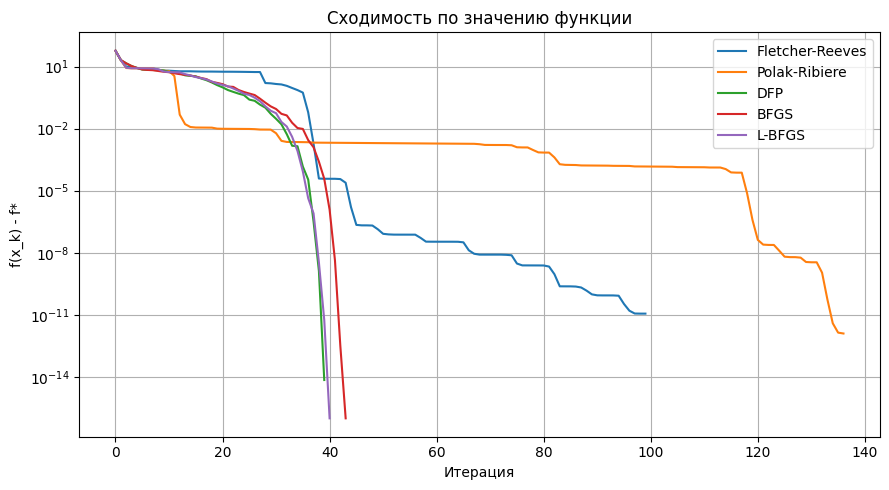

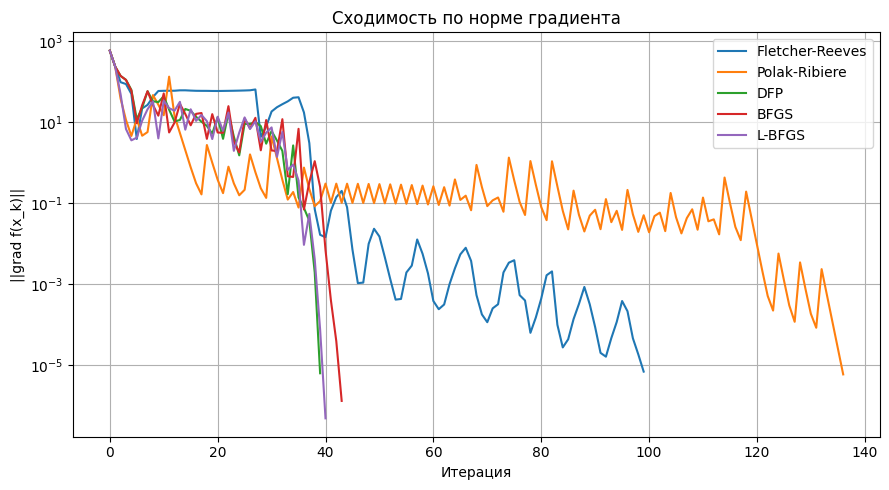

In [10]:

def history_dataframe(result):
    return pd.DataFrame({
        'iter': [h['iter'] for h in result.history],
        'f': [h['f'] for h in result.history],
        'grad_norm': [h['grad_norm'] for h in result.history],
    })

plt.figure(figsize=(9, 5))
for res in methods:
    hdf = history_dataframe(res)
    plt.plot(hdf['iter'], np.maximum(hdf['f'] - f_expected, 1e-16), label=res.method)
plt.yscale('log')
plt.xlabel('Итерация')
plt.ylabel('f(x_k) - f*')
plt.title('Сходимость по значению функции')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('lab3_convergence_function.png', dpi=180)
plt.show()

plt.figure(figsize=(9, 5))
for res in methods:
    hdf = history_dataframe(res)
    plt.plot(hdf['iter'], np.maximum(hdf['grad_norm'], 1e-16), label=res.method)
plt.yscale('log')
plt.xlabel('Итерация')
plt.ylabel('||grad f(x_k)||')
plt.title('Сходимость по норме градиента')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('lab3_convergence_gradient.png', dpi=180)
plt.show()


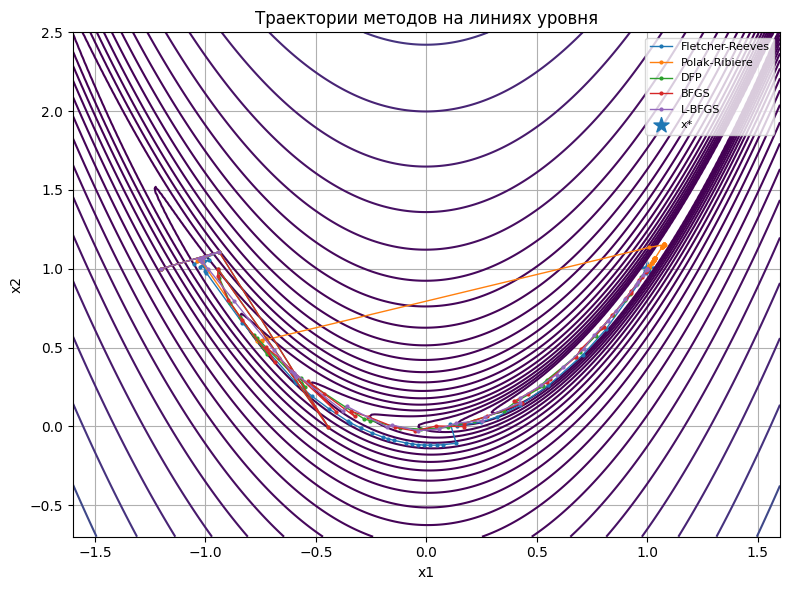

In [11]:

if n == 2:
    x1_grid = np.linspace(-1.6, 1.6, 240)
    x2_grid = np.linspace(-0.7, 2.5, 240)
    X1, X2 = np.meshgrid(x1_grid, x2_grid)
    Z = np.zeros_like(X1)
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            Z[i, j] = rosenbrock_generalized(np.array([X1[i, j], X2[i, j]]))

    plt.figure(figsize=(8, 6))
    levels = np.logspace(0, 4, 25) + f0
    plt.contour(X1, X2, Z, levels=levels)
    for res in methods:
        xy = np.array([h['x'] for h in res.history])
        plt.plot(xy[:, 0], xy[:, 1], marker='o', markersize=2, linewidth=1, label=res.method)
    plt.scatter([1], [1], marker='*', s=130, label='x*')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Траектории методов на линиях уровня')
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('lab3_trajectories.png', dpi=180)
    plt.show()
else:
    print('Для n > 2 траектория на плоскости не строится.')



## 10. Выводы

1. Все реализованные методы нашли минимум в точке, близкой к $x^*=(1,\dots,1)$.
2. Значение функции в найденной точке совпадает с теоретическим минимумом $f_0$ с малой численной погрешностью.
3. По числу итераций и времени работы квазиньютоновские методы обычно быстрее методов сопряженных градиентов.
4. В выбранном запуске BFGS и L-BFGS дают устойчивую быструю сходимость, а метод Полака-Рибьера с перезапусками может потребовать больше итераций.
